# 🌸 Iris Species Classification
**Task:** Build a multi-class classifier on the classic Iris dataset  
**Models:** K-Nearest Neighbours · Logistic Regression · Decision Tree  
**Author:** AI Researcher | InternSpark Task Submission  
**Dataset:** [Kaggle – Iris Classification Dataset](https://www.kaggle.com/datasets/bhanupratapbiswas/iris-classification-dataset)


## 0. Environment Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
import joblib, warnings
warnings.filterwarnings('ignore')
print('Libraries loaded ✓')


## 1. Data Loading & Inspection

In [ ]:
df = pd.read_csv('IRIS.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Missing values:\n{df.isnull().sum()}')
df.head()


In [ ]:
print('Class distribution:')
print(df['species'].value_counts())
print('\nDescriptive statistics:')
df.describe().round(3)


## 2. Exploratory Data Analysis

### 2.1 Class Distribution


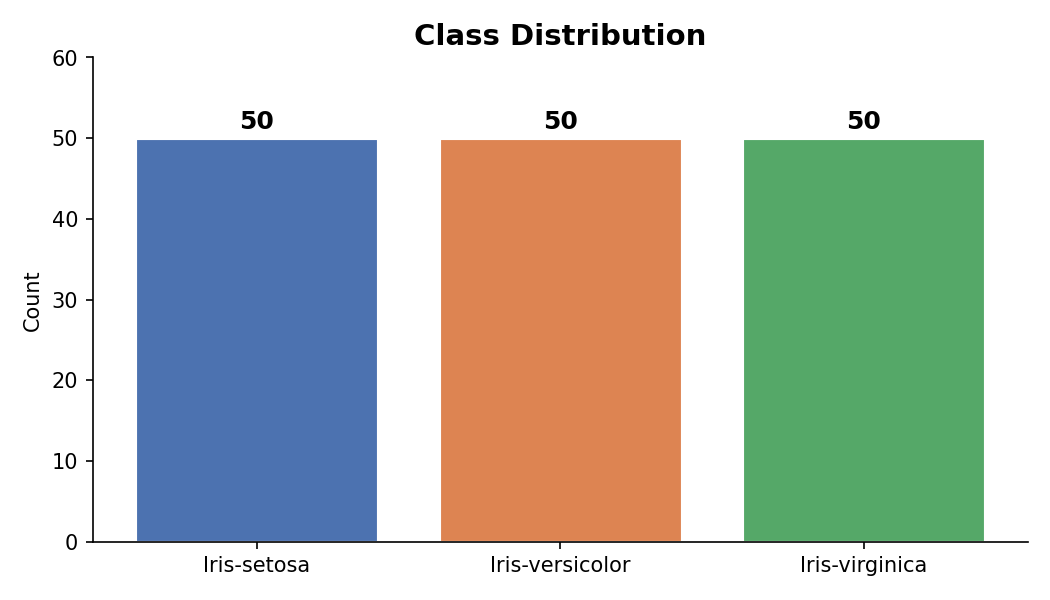

In [ ]:
# Class Distribution

### 2.2 Feature Distributions by Species (Violin Plots)

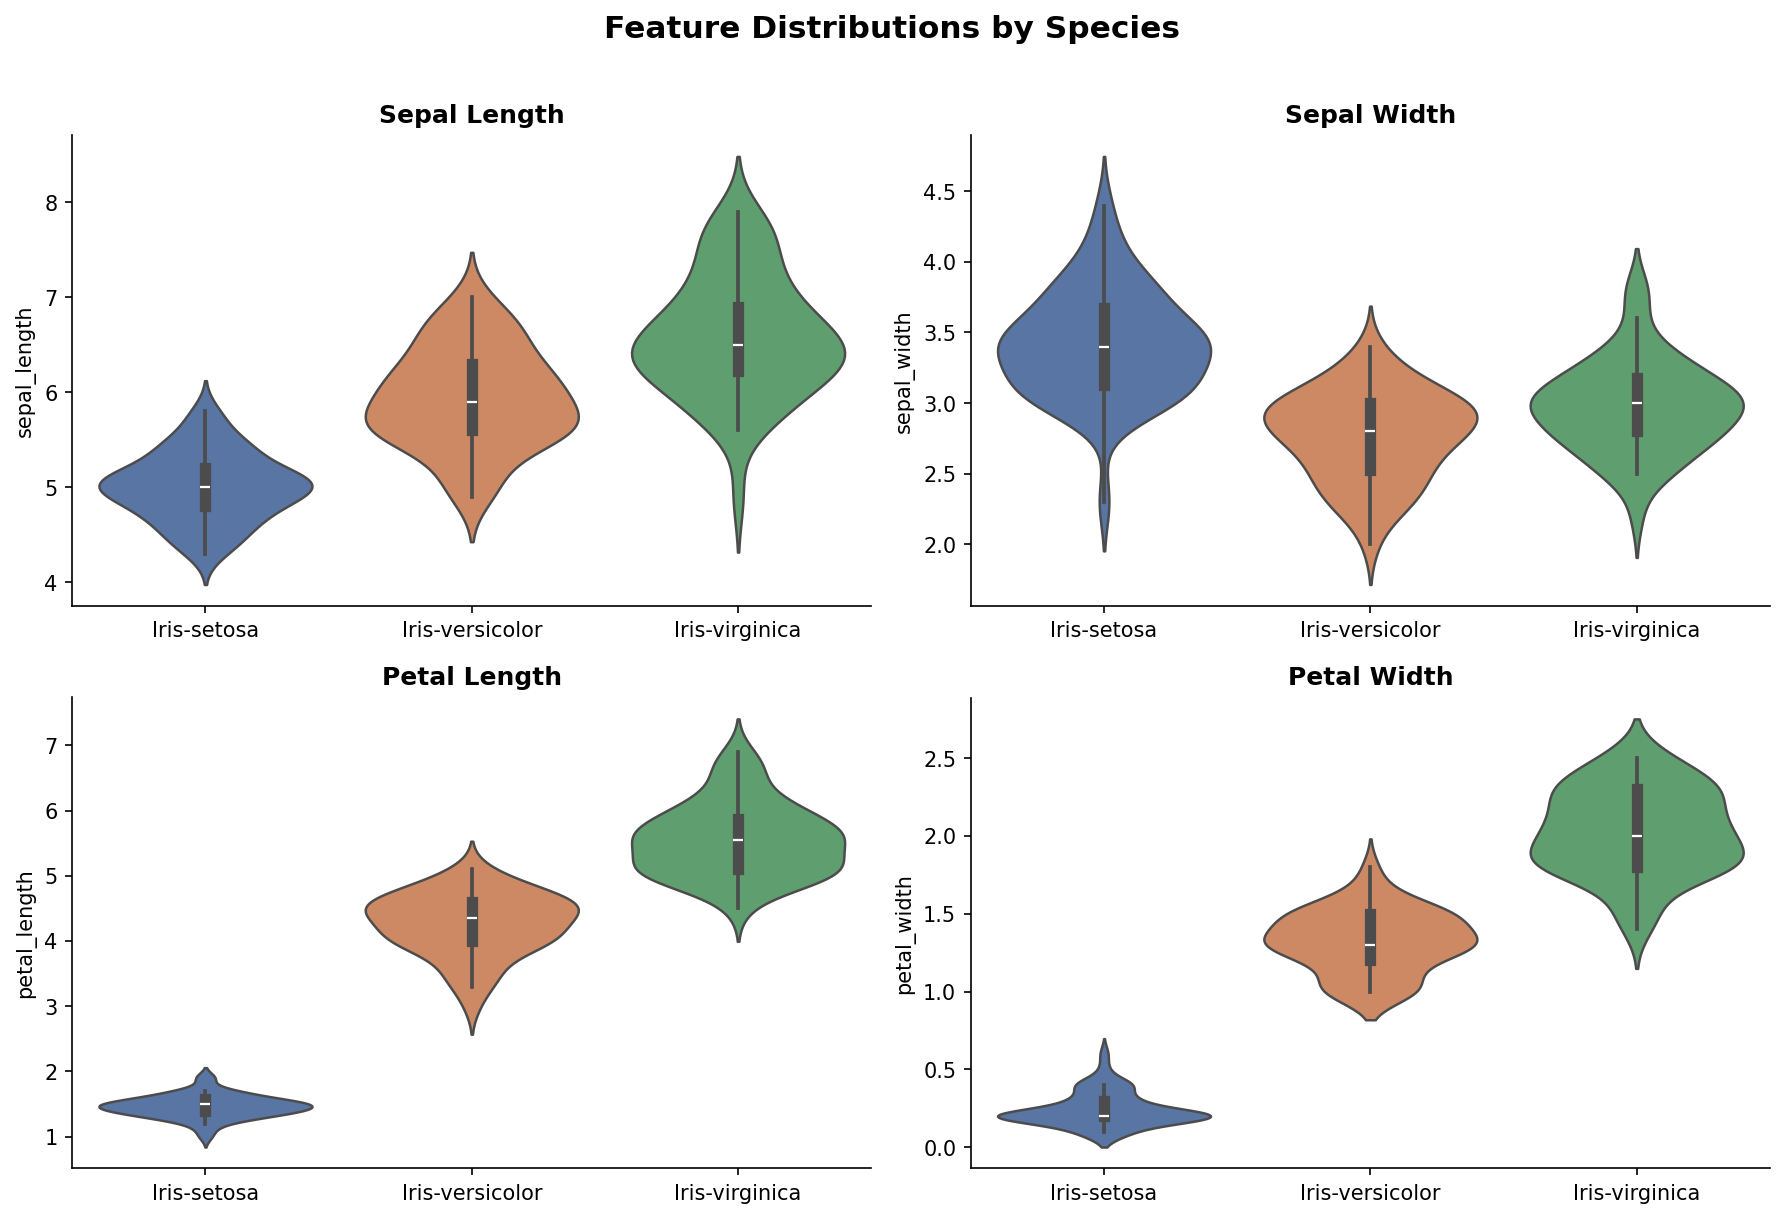

In [ ]:
# Violin Plots

### 2.3 Pairplot — Class Separability

> **Insight:** Petal length and petal width show near-perfect linear separability between *setosa* and the other two classes. *Versicolor* and *virginica* overlap slightly.


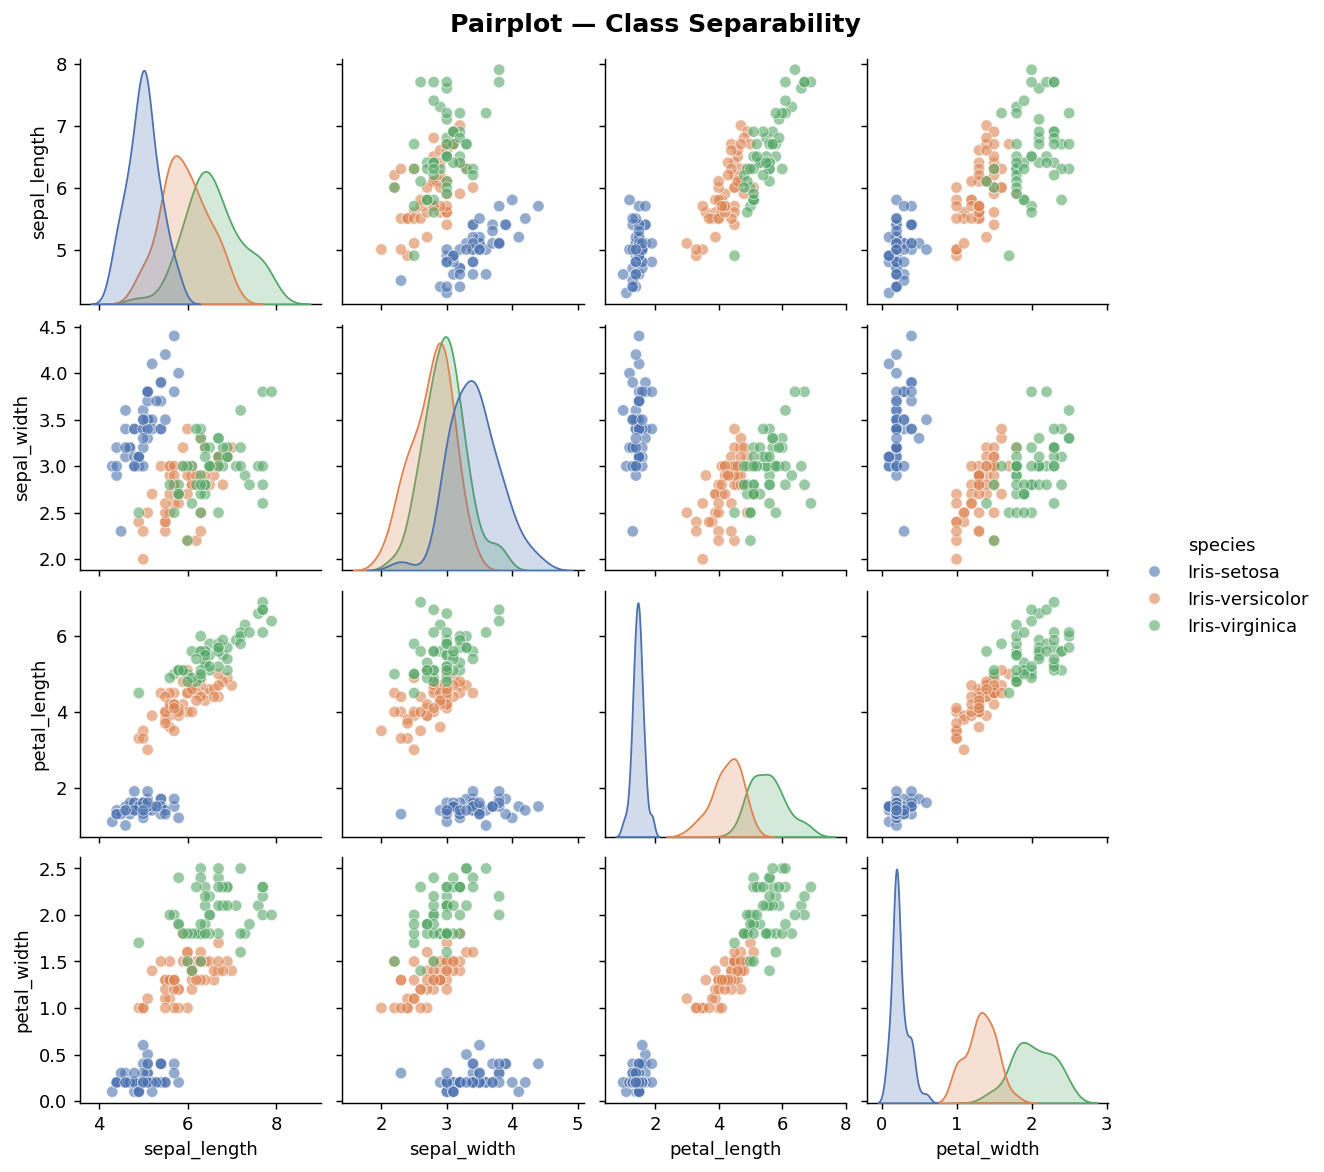

In [ ]:
# Pairplot

### 2.4 Correlation Heatmap

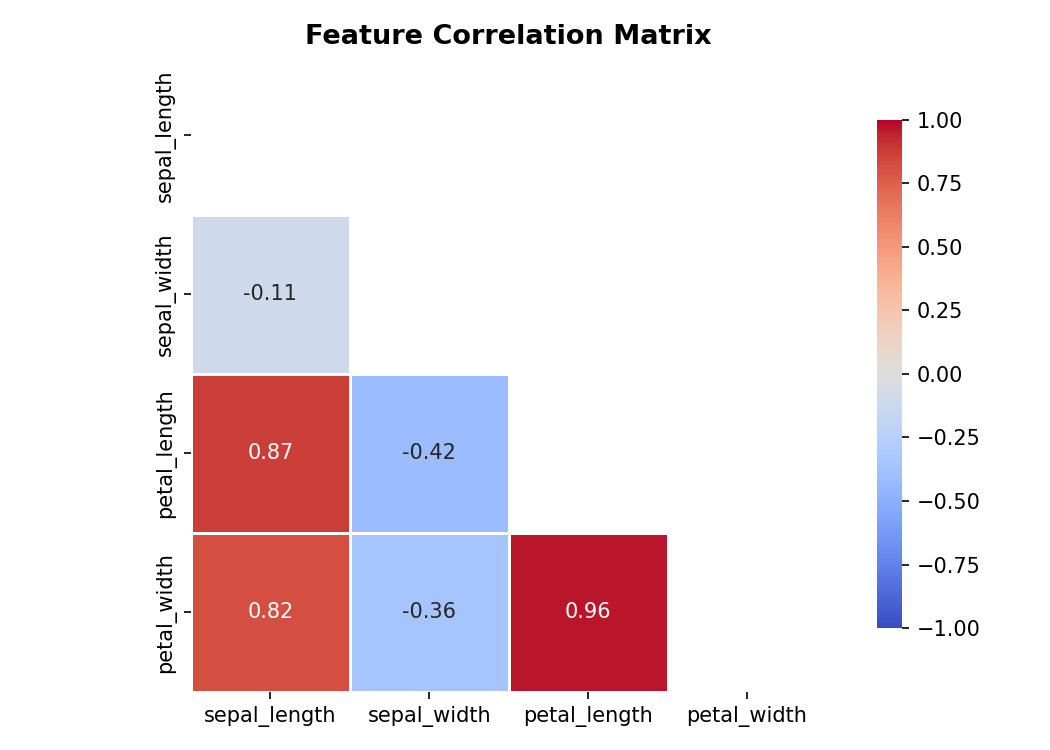

In [ ]:
# Correlation Heatmap

## 3. Pre-processing

In [ ]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['species'])
FEATURES = ['sepal_length','sepal_width','petal_length','petal_width']
X = df[FEATURES].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f'Train: {X_train_sc.shape} | Test: {X_test_sc.shape}')


## 4. Model Training & Evaluation

In [ ]:
models = {
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=4, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, clf in models.items():
    clf.fit(X_train_sc, y_train)
    y_pred = clf.predict(X_test_sc)
    acc   = accuracy_score(y_test, y_pred)
    cv_sc = cross_val_score(clf, X_train_sc, y_train, cv=cv, scoring='accuracy')
    cm    = confusion_matrix(y_test, y_pred)
    cr    = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
    results[name] = dict(clf=clf, acc=acc, cv_mean=cv_sc.mean(),
                         cv_std=cv_sc.std(), cm=cm, cr=cr, y_pred=y_pred)
    print(f'\n── {name} ──')
    print(f'  Test Accuracy : {acc:.4f}')
    print(f'  CV  Accuracy  : {cv_sc.mean():.4f} ± {cv_sc.std():.4f}')
    print(classification_report(y_test, y_pred, target_names=le.classes_))


### 4.1 Confusion Matrices

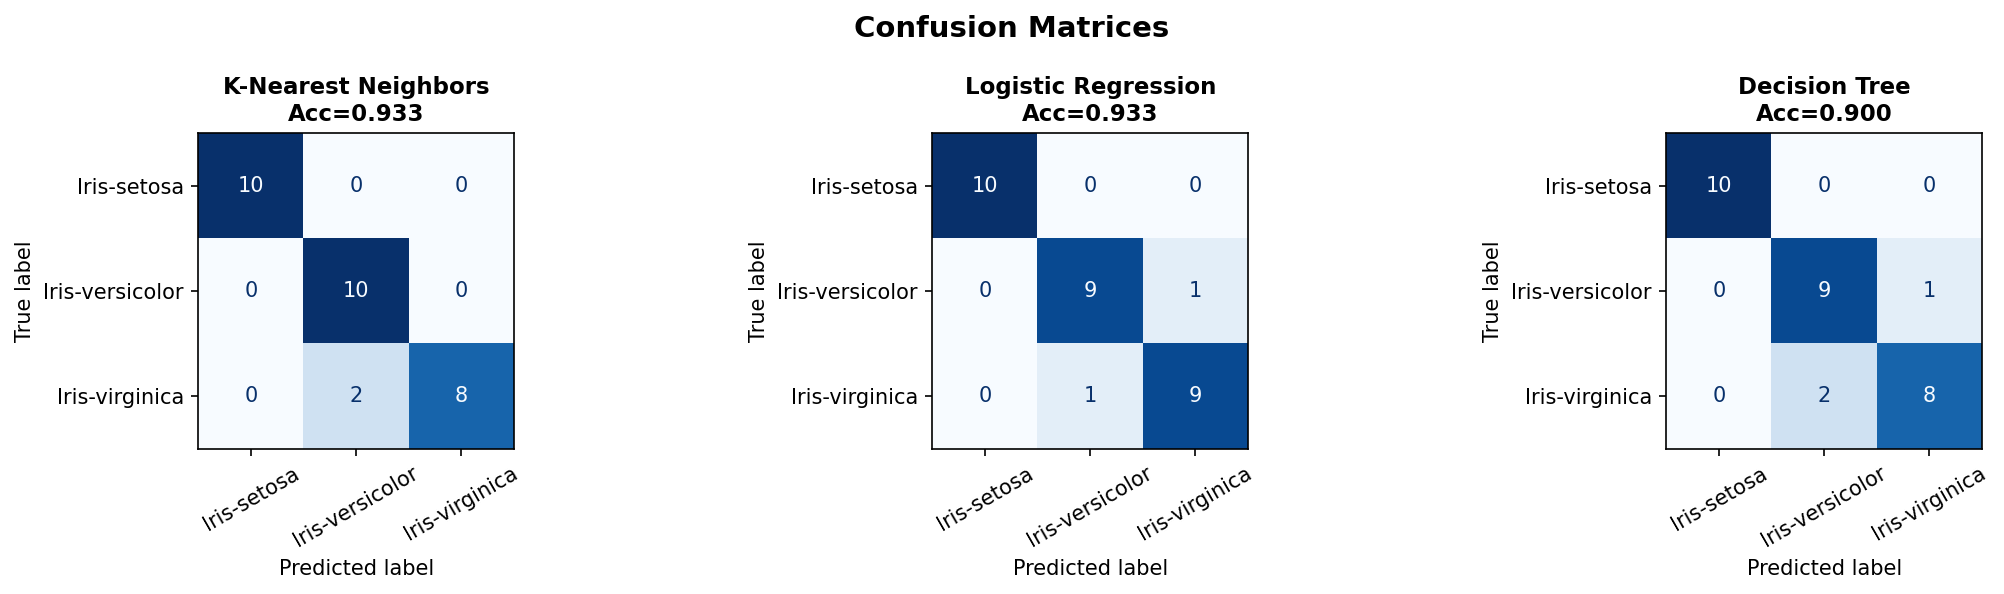

In [ ]:
# Confusion Matrices

### 4.2 Model Comparison

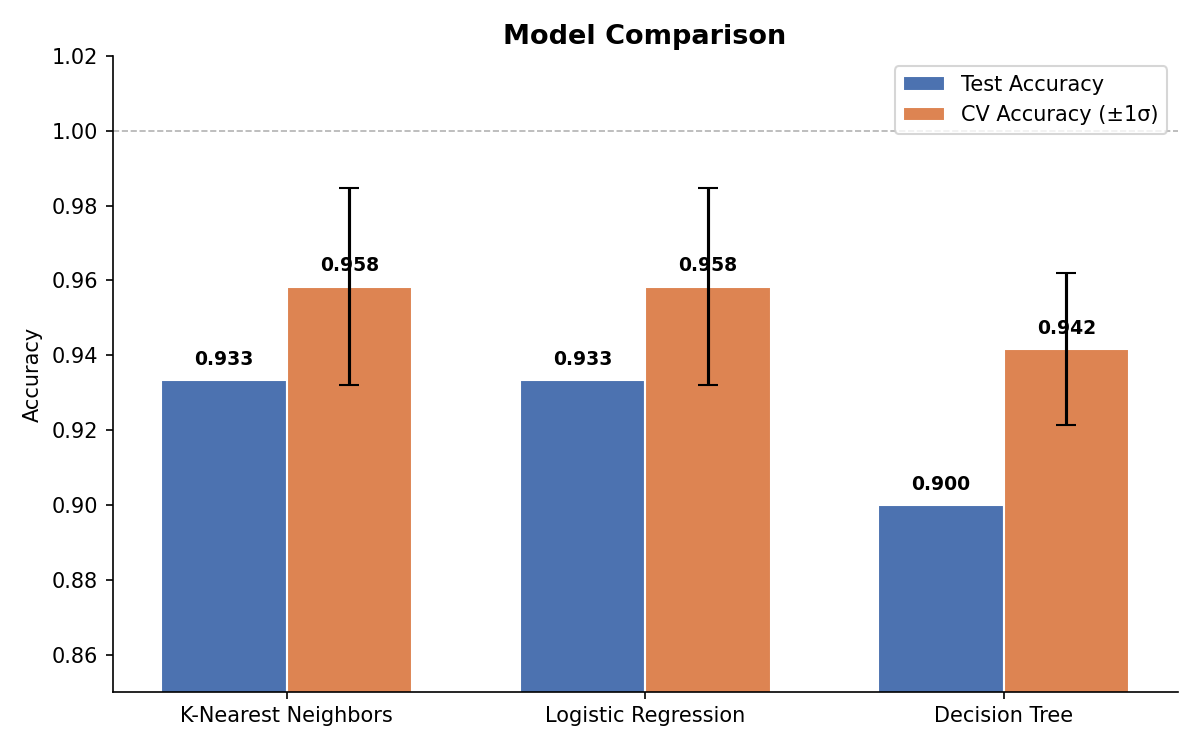

In [ ]:
# Model Comparison

### 4.3 Decision Tree Structure

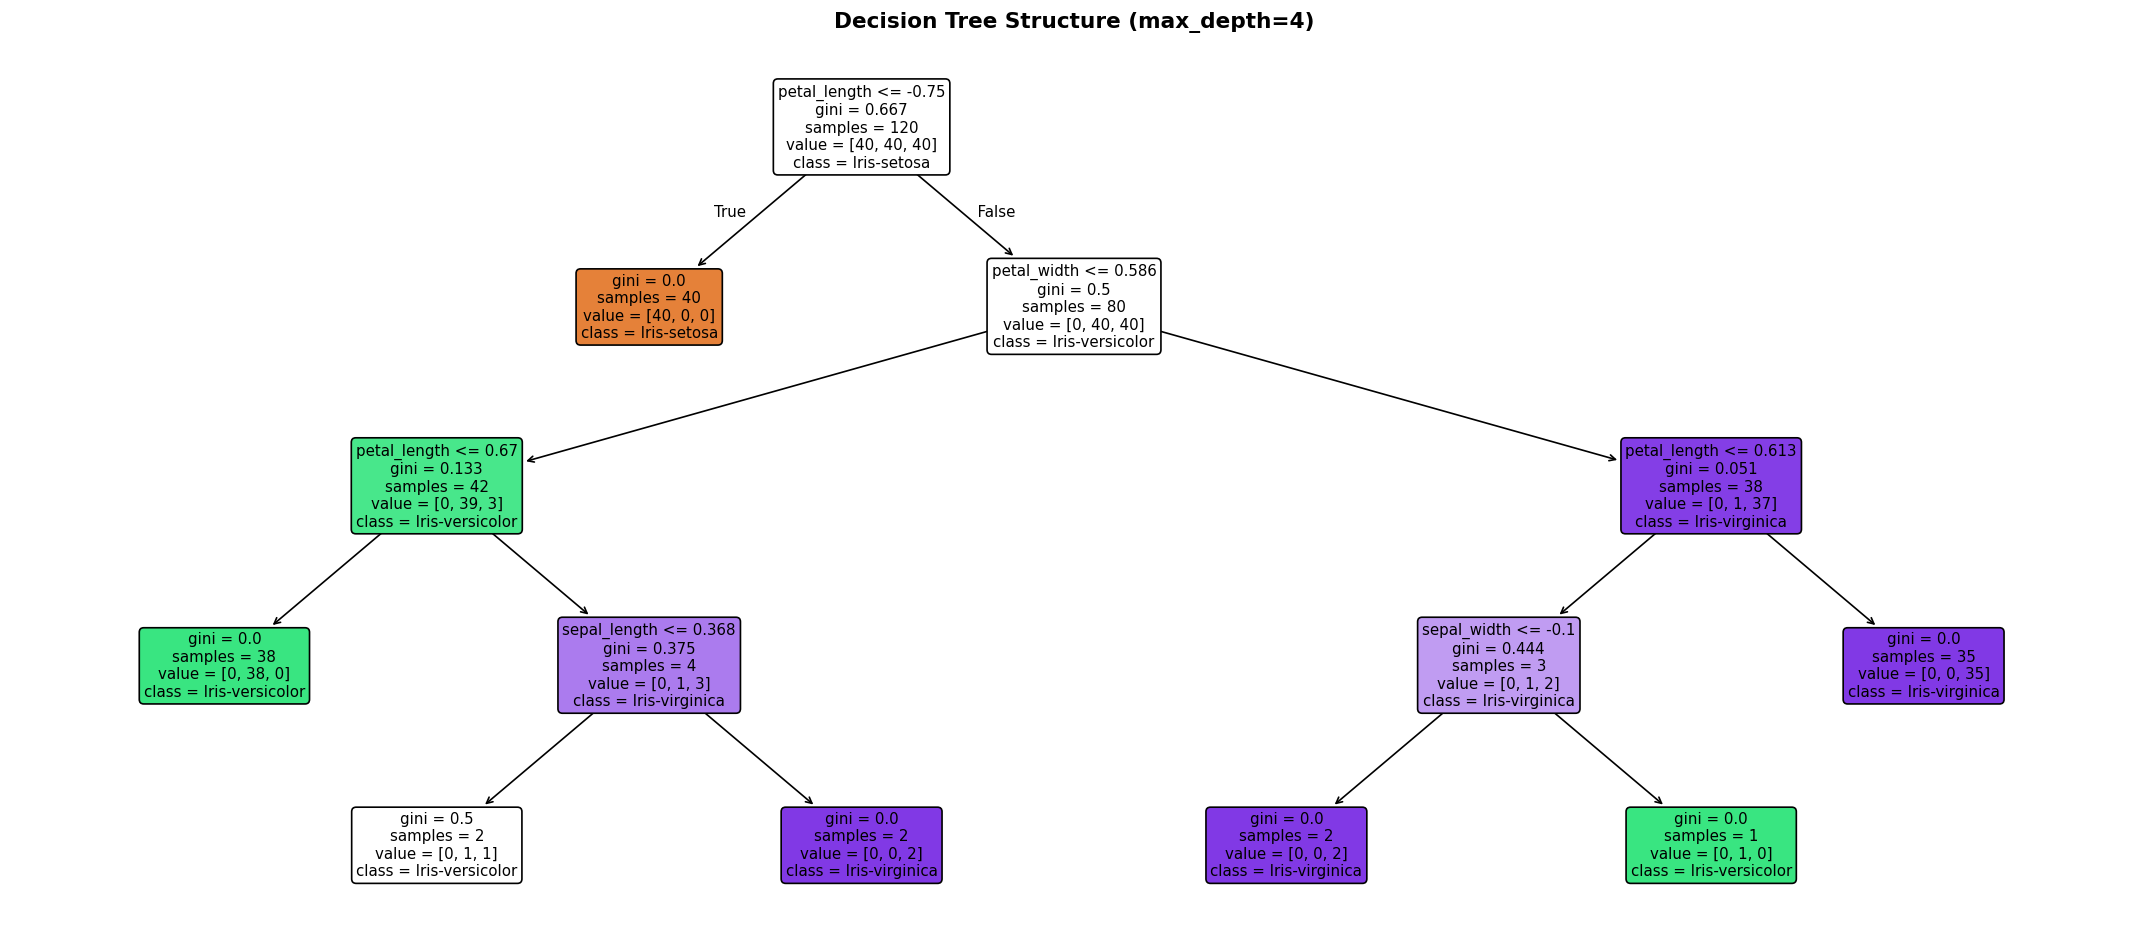

In [ ]:
# Decision Tree

## 5. Save Best Model

In [ ]:
best_name = max(results, key=lambda n: results[n]['cv_mean'])
print(f'Best model: {best_name}')

bundle = {'model': results[best_name]['clf'],
          'scaler': scaler,
          'label_encoder': le,
          'feature_names': FEATURES}
joblib.dump(bundle, 'iris_best_model.joblib')
print('Saved iris_best_model.joblib ✓')


## 6. Inference Example

In [ ]:
# ── Load & infer ──────────────────────────────────────────────────────────
bundle   = joblib.load('iris_best_model.joblib')
clf      = bundle['model']
scaler   = bundle['scaler']
le       = bundle['label_encoder']
features = bundle['feature_names']

sample = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=features)
scaled = scaler.transform(sample)
pred   = clf.predict(scaled)
proba  = clf.predict_proba(scaled)   # available for KNN & LR

print(f'Predicted species : {le.inverse_transform(pred)[0]}')
print(f'Class probabilities:')
for cls, p in zip(le.classes_, proba[0]):
    print(f'  {cls:<20} {p:.4f}')
